# Lab 7.06 - Time series analysis

In [1]:
# Package imports
# Importing the necessary packages
import numpy as np                                  # Scientific computing
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Exercise 6: COVID-19 data


In this lab assignment, we will make use of the COVID-19 dataset maintained by [Our World in Data](https://ourworldindata.org/coronavirus), published on Github at <https://github.com/owid/covid-19-data/tree/master/public/data>.

We took a snapshot of the data on 2023-05-31 that still contains *daily* observations. Recently, the dataset has been updated to only contain weekly observations.

First, we import the dataset, parse the `date` column as the Python `DateTime` type and set this as the index.

**Tip:** The CSV file is rather large, so instead you may want to load a local copy of the CSV file to avoid downloading it multiple times ('../data/owid-covid-data-2023-05-31.csv').

In [3]:
covid19 = pd.read_csv(
    '../data/owid-covid-data-2023-05-31.csv',
    parse_dates=['date'],
    index_col=['date'])
covid19.head()

,iso_code,continent,location,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,AFG,Asia,Afghanistan,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2020-01-04,AFG,Asia,Afghanistan,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2020-01-05,AFG,Asia,Afghanistan,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2020-01-06,AFG,Asia,Afghanistan,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2020-01-07,AFG,Asia,Afghanistan,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN


Create a new `DataFrame` (with name e.g. `covid19_be`) that only contains the new cases in Belgium and use the `plot()` method of `DataFrame` to visualize it. Increase the size of the picture with the `figsize` parameter, otherwise it will be too small.

<Axes: xlabel='date'>

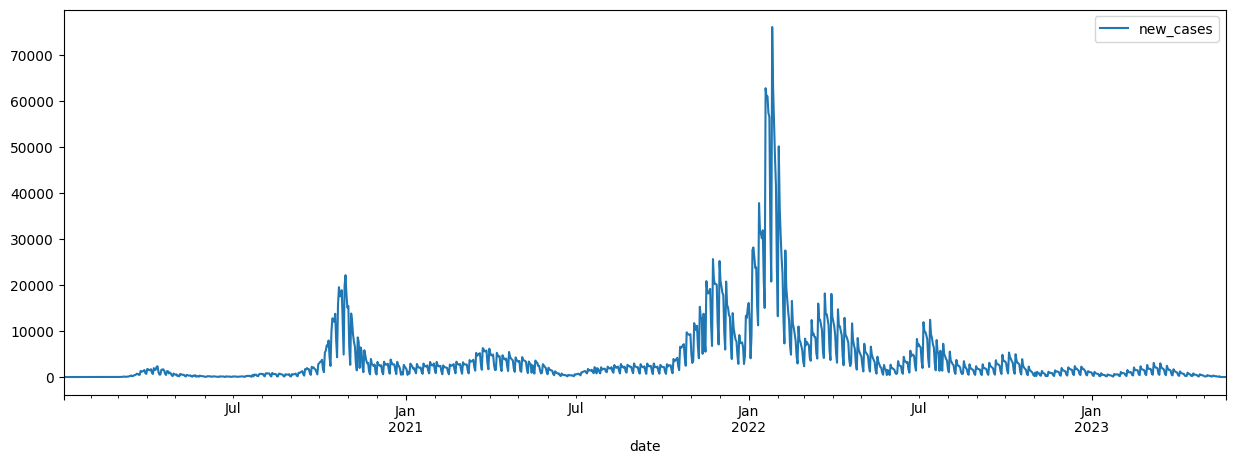

In [24]:
covid19_be = pd.DataFrame(covid19[covid19['iso_code'] == 'BEL']['new_cases'])
covid19_be.plot(figsize=(15,5))

### Moving average

Add new columns to the data frame with new cases in Belgium with the simple moving average for 7 and 30 days. Plot the entire data frame (observations and both moving averages).

<Axes: xlabel='date'>

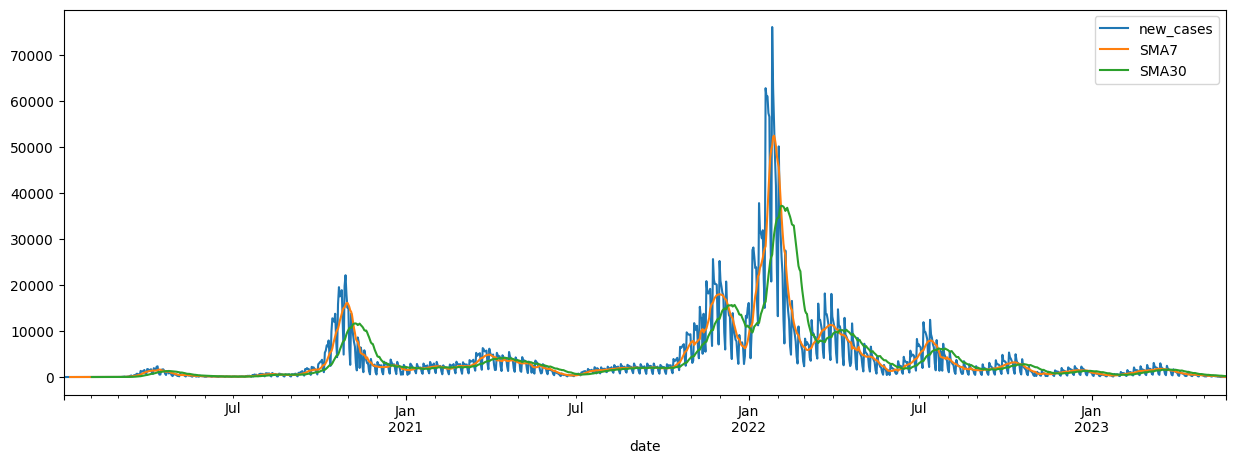

In [30]:
covid19_be['SMA7'] = covid19_be['new_cases'].rolling(7).mean().shift(1)
covid19_be['SMA30'] = covid19_be['new_cases'].rolling(30).mean().shift(1)

covid19_be.plot(y=['new_cases', 'SMA7', 'SMA30'], figsize=(15,5))


### Holt-Winters model for new cases early 2021

The period from about December 2020 up to the end of February 2021 seems quite regular. Create a new `DataFrame` and select only the observations during that period (1 December 2020 to 28 February 2021). Plot the `DataFrame` (it will still contain the moving averages from the previous step).

<Axes: xlabel='date'>

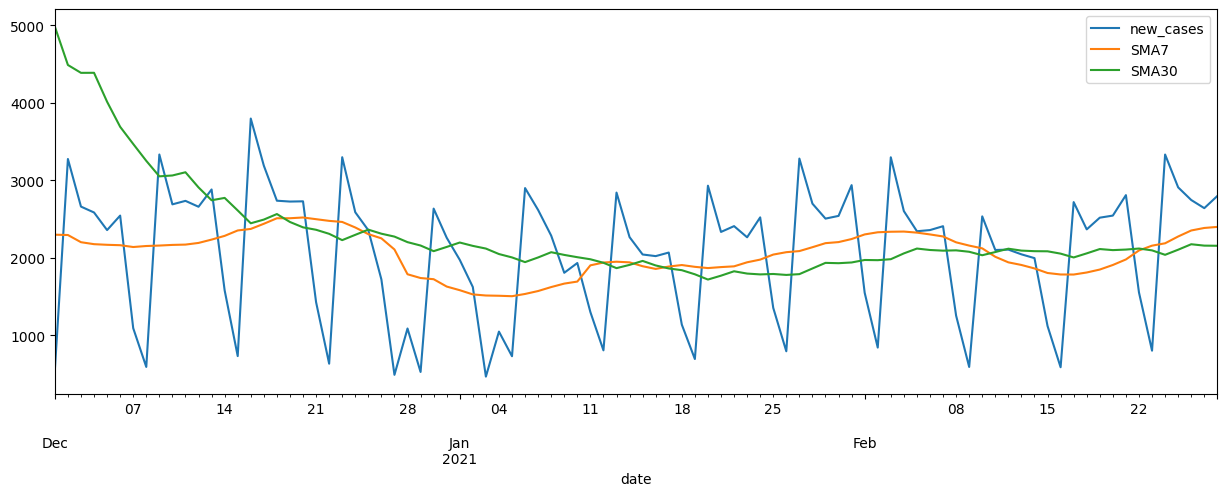

In [36]:
covid19_be_early_2021 = covid19_be['2020-12-01':'2021-02-28']
covid19_be_early_2021.plot(figsize=(15,5))



Build a Holt-Winters model for the observed new cases during that period.

Use the additive type for both trend and seasonal smoothing. Set the value for `seasonal_periods` to the appropriate value! Plot the observed and fitted values.

c:\Users\Jelle\Documents\Hogent\Toegepaste-Informatica-Hogent\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


<Axes: xlabel='date'>

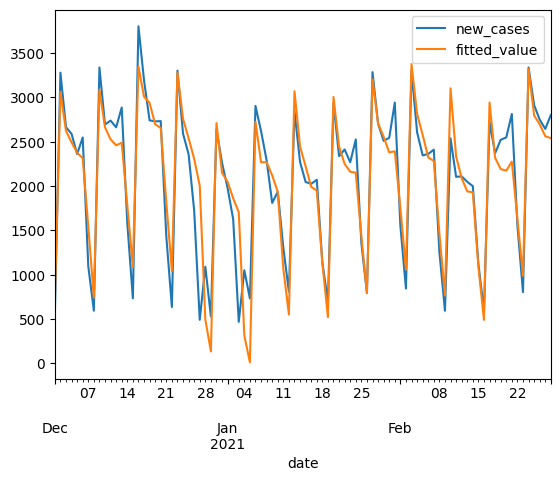

In [39]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
tes_model = ExponentialSmoothing(covid19_be_early_2021['new_cases'], trend='add', seasonal='add', seasonal_periods=7).fit()
covid19_be_early_2021['fitted_value'] = tes_model.fittedvalues

covid19_be_early_2021.plot(y=['new_cases', 'fitted_value'])

Now, make a forecast for 21 days and plot observed and forecasted values. What do you notice when you compare observed and forecasted values as time progresses?

<Axes: xlabel='date'>

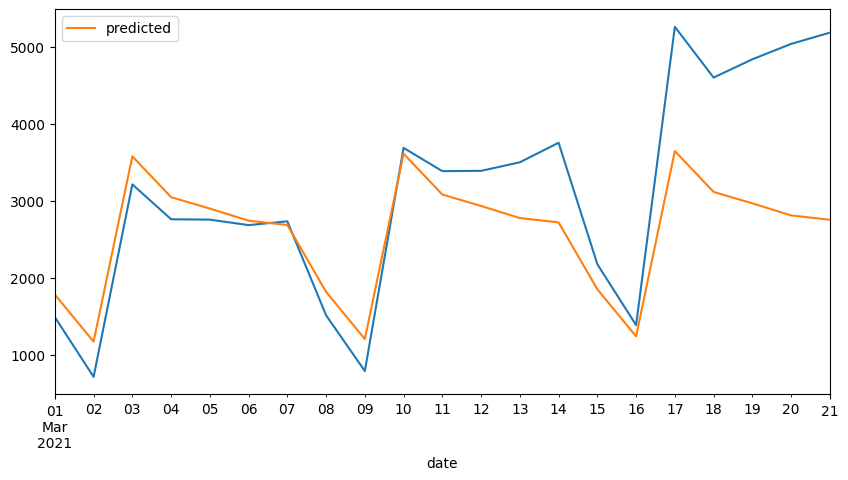

In [43]:
fcast = tes_model.forecast(21)
y_true = covid19_be['2021-03-01':'2021-03-21']['new_cases']

y_true.plot(figsize=(10,5))
fcast.plot(legend=True, label='predicted')


The more time goes by, the less accurate this model becomes.

### Evaluating model quality


- Calculate the Mean Squared Error for a forecast period of 7 days, and compare its square root with the standard deviation of observed new cases over the test period and forecasted period combined.
- Do the same for a forecast period of 14 and 21 days.
- For which period is the quality of the forecast ok?

The expected results are shown in the table below:

|     Forecast period      |         MSE |     √MSE |    stdev |
| :----------------------: | ----------: | -------: | -------: |
| 2021-03-01 to 2021-03-07 |   25408.902 |  159.402 |  855.684 |
| 2021-03-01 to 2021-03-14 |  154280.817 |  392.786 |  895.531 |
| 2021-03-01 to 2021-03-21 | 1048835.781 | 1024.127 | 1052.978 |

In [69]:
from sklearn.metrics import mean_squared_error

def calculate_mse(length):
    true=y_true[:length].values
    pred=fcast.values[:length]
    mse = mean_squared_error(true, pred)
    mse_root = np.sqrt(mse)
    stdev = true.std() + pred.std()
    print(f'Voor een periode van {length} dagen is de mse {mse}, de vierkantswortel van mse {mse_root} en de standaardafwijking {stdev}')

calculate_mse(7)
calculate_mse(14)
calculate_mse(21)

# NOTE: de values hierboven kloppen niet met de lesopnames. De uitkomsten van de functie voor mse komen overeen met de lesopnames. 
# Geen idee of dit juist is.


Voor een periode van 7 dagen is de mse 76566.12248274642, de vierkantswortel van mse 276.705841070886 en de standaardafwijking 1577.4740972888299
Voor een periode van 14 dagen is de mse 193067.6746830501, de vierkantswortel van mse 439.3946684736287 en de standaardafwijking 1763.2520093521048
Voor een periode van 21 dagen is de mse 1048372.7069432152, de vierkantswortel van mse 1023.9007310004301 en de standaardafwijking 2127.7759432691673


### ICU patients

Create a new `DataFrame` with only the total number of ICU (intensive care units) patients in the Belgian hospitals. Make sure that all NaN's are removed, since time series analysis functions can't cope with missing values. Plot this time series. 

<Axes: xlabel='date'>

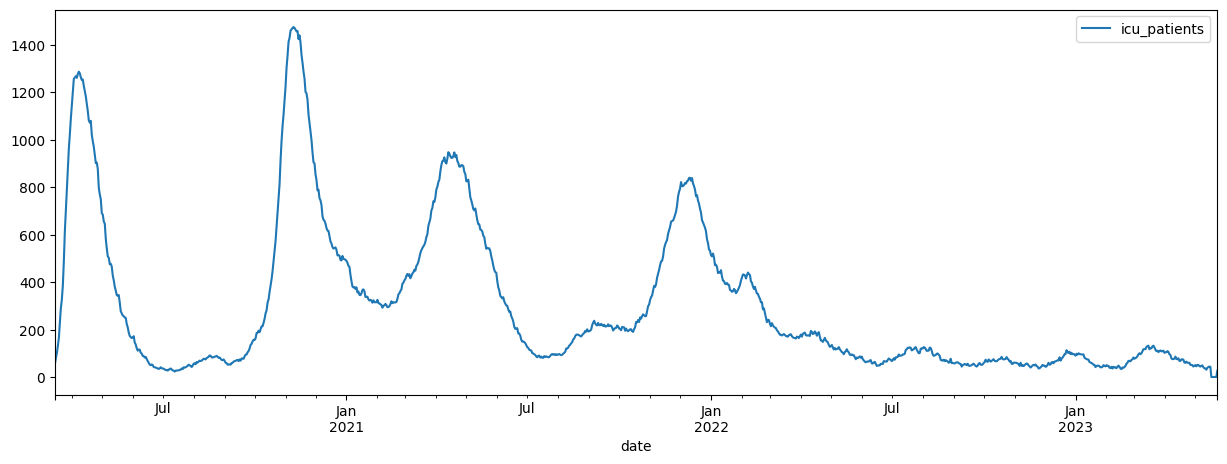

In [89]:
icu_patients = covid19[covid19['location'] == 'Belgium'][['icu_patients']]
icu_patients = icu_patients.dropna()
icu_patients.plot(y='icu_patients', figsize=(15,5))

Build a duible exponential smoothing (Holt) model of this time series. Make a forecast of 70 time units and plot the observations, fitted values and forecast.

Are we currently in an upward or downward trend, according to this model? Do the forecasted values seem reasonable if you look at the last period?

The forecast does not look reasonable. The reason that it's increasing so fast is because the trend is positive at the end of the training data.


c:\Users\Jelle\Documents\Hogent\Toegepaste-Informatica-Hogent\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


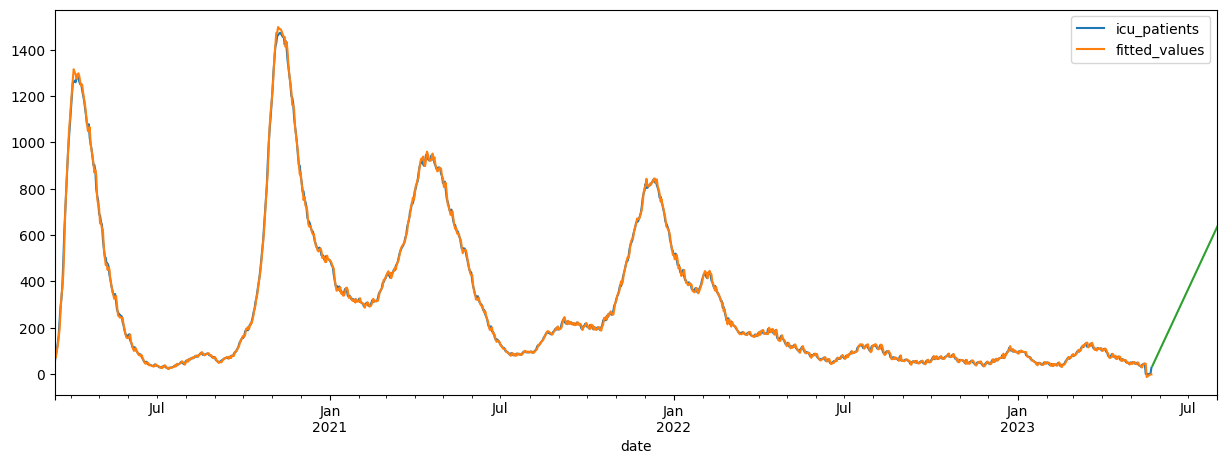

In [100]:
from statsmodels.tsa.holtwinters import Holt
model = Holt(icu_patients['icu_patients']).fit()
forecast = model.forecast(70)
icu_patients['fitted_values'] = model.fittedvalues

icu_patients.head()

icu_patients.plot(figsize=(15,5))
forecast.plot()

print('The forecast does not look reasonable. The reason that it\'s increasing so fast is because the trend is positive at the end of the training data.')

Since we didn't set any initial parameters like $\alpha$ and $\beta$, the model calculated them using some rule of thumb. List these parameters from the model:

In [102]:
model.params_formatted

,name,param,optimized
smoothing_level,alpha,0.958466,True
smoothing_trend,beta,0.373023,True
initial_level,l.0,53.000000,False
initial_trend,b.0,26.000000,False


What were the final estimated values for the level and trend, that are used in the forecast? In other words, what are the parameters of the line that estimates future observations?

In [104]:
print(f'last level:{model.level.iloc[-1]}')
print(f'last trend:{model.trend.iloc[-1]}')

last level:25.812017521613768
last trend:8.73148571103426


Let's try to set the parameters ourselves. Recreate the Holt-model with $\alpha = \beta = 0.1$. Calculate a forecast like before and plot.

c:\Users\Jelle\Documents\Hogent\Toegepaste-Informatica-Hogent\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


<Axes: xlabel='date'>

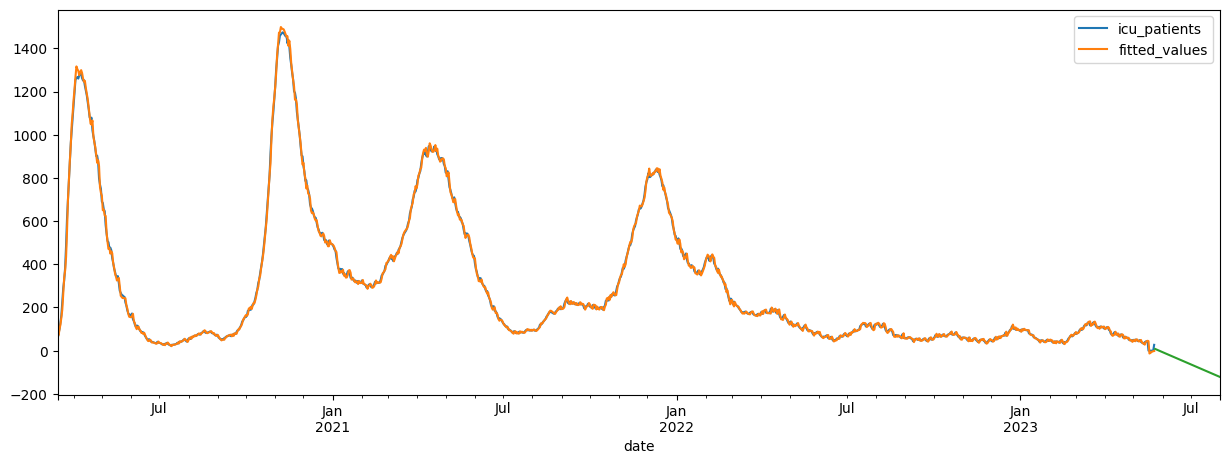

In [105]:
model = Holt(icu_patients.icu_patients).fit(smoothing_level=0.1, smoothing_trend=0.1, optimized=False)
forecast = model.forecast(70)

icu_patients.plot(figsize=(15,5))
forecast.plot()

Compare the model parameters and final estimates. Which of the two forecast models seems to perform best if you look at the plots?

In [106]:
print(f'last level:{model.level.iloc[-1]}')
print(f'last trend:{model.trend.iloc[-1]}')

last level:9.91537669812055
last trend:-1.8855731983284
